### Machine learning

To take decisions from data by itself.  

### Supervised learning
where the values to be predicted are know already. they are labeled data. use features to predit values of target variable.

types:
1. classification: binary, i.e target variable is categorical
2. Regression: Target variable is continous

from sklearn.module import Model - import (a type of algorith for supervised learning) Eg: k nearest model
model = Model() - we create a varibled named model, and instantiate the model
model.fit(X, y) - we are fitting that model above to the data, where it learns about the features and target variables
x - is array of features, y is array of taget variables modules
predictions = model.predict(X_new) - use the model .predict() method, by passing new x variables. 
print(predictions) - now get array of y results. 


## Building a classification model. of unseen data

1. Build a model
2. Model learns from the labeled data we pass to it (training data)
3. pass unlabeled data to model as input
4. model predicts the labels of unseen data


# Classificattion

## K-nearest neighbhours 
1. Look at there k closest data point
2. and take the majority vote

In [1]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv(r"C:\Users\vshnu\OneDrive\Desktop\Vishnuperson\RE\aspire_\learn\Datacamp\3_supervised_learing_with_scikit\telecom_churn_clean.csv")


In [5]:
df.head(3)

,Unnamed: 0,account_length,area_code,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,customer_service_calls,churn
0,0,128,415,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,1,107,415,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,2,137,415,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0


In [10]:
from sklearn.neighbors import KNeighborsClassifier

In [19]:
X = df[["total_day_charge","total_eve_charge"]].values
y = df["churn"].values

In [17]:
knn = KNeighborsClassifier(n_neighbors=6)
knn

KNeighborsClassifier(n_neighbors=6)

In [20]:
knn.fit(X,y)

KNeighborsClassifier(n_neighbors=6)

In [ ]:
knn.predict()

In [23]:
X_new = np.array([[30.0, 17.5],
                  [107.0, 24.1],
                  [213.0, 10.9]])

In [24]:
y_new = knn.predict(X_new)

print(y_new)

[0 1 1]


## Measuring Model performance

use accuracy: accuracy = correct predictions/total observations
for this we need to split to train and test. 

In [25]:
df.head(1)

,Unnamed: 0,account_length,area_code,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,customer_service_calls,churn
0,0,128,415,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.7,1,0


In [ ]:
from sklearn.model_selection import train_test_split

#create array of ind & dep variables
X = df.drop("churn", axis=1).values
y = df["churn"].values

#split you data to train & test, test_size is defined, it is randomly done and stratify on y
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42, stratify=y)

#instantiate the mode
knn = KNeighborsClassifier(n_neighbors=5)

#provide train variables to learn from 
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
#check how accurate is result set with test set
print(knn.score(X_test, y_test))

0.8545727136431784


In [31]:
#it is quite less, we go ahead and iterate to find the right k value. for that do for loop for set of k values

k = np.arange(1,26)
train_accuracies = {}
test_accuracies = {}


for val in k:
    knn = KNeighborsClassifier(n_neighbors=val)

    knn.fit(X_train, y_train)

    train_accuracies[val] = knn.score(X_train,y_train)
    test_accuracies[val] = knn.score(X_test,y_test)

print(k, '\n', train_accuracies, '\n', test_accuracies)

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25] 
 {np.int64(1): 1.0, np.int64(2): 0.8885971492873218, np.int64(3): 0.8994748687171793, np.int64(4): 0.8750937734433608, np.int64(5): 0.878469617404351, np.int64(6): 0.8660915228807202, np.int64(7): 0.8705926481620405, np.int64(8): 0.8615903975993998, np.int64(9): 0.86384096024006, np.int64(10): 0.858589647411853, np.int64(11): 0.8604651162790697, np.int64(12): 0.8574643660915229, np.int64(13): 0.858589647411853, np.int64(14): 0.8567141785446362, np.int64(15): 0.858589647411853, np.int64(16): 0.8574643660915229, np.int64(17): 0.8582145536384096, np.int64(18): 0.8567141785446362, np.int64(19): 0.8570892723180795, np.int64(20): 0.8563390847711928, np.int64(21): 0.8567141785446362, np.int64(22): 0.8559639909977494, np.int64(23): 0.8563390847711928, np.int64(24): 0.8555888972243061, np.int64(25): 0.8559639909977494} 
 {np.int64(1): 0.7856071964017991, np.int64(2): 0.8470764617691154, np.int64(3): 0.832083958020989

In [35]:
import matplotlib.pyplot as plt

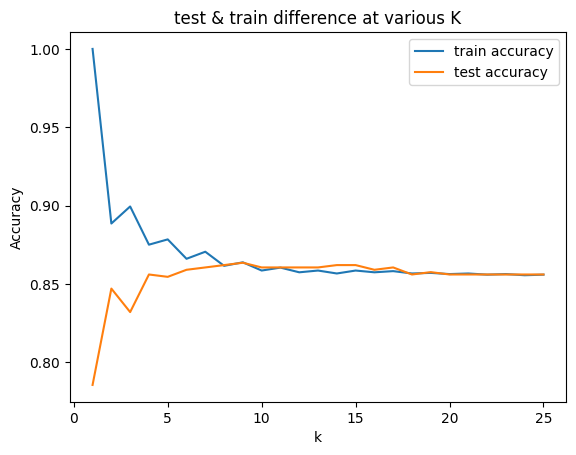

In [36]:
plt.title("test & train difference at various K")

plt.plot(k, train_accuracies.values(), label="train accuracy")
plt.plot(k, test_accuracies.values(), label="test accuracy")

plt.legend()
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.show()

# Regression

In [40]:
from sklearn.linear_model import LinearRegression

In [41]:
df1 = pd.read_csv(r"C:\Users\vshnu\OneDrive\Desktop\Vishnuperson\RE\aspire_\learn\Datacamp\3_supervised_learing_with_scikit\diabetes_clean.csv")

In [42]:
df1.head(2)

,pregnancies,glucose,diastolic,triceps,insulin,bmi,dpf,age,diabetes
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0


In [44]:
X = df1["bmi"].values
y = df1["glucose"].values

X = X.reshape(-1,1)

print(X.shape, y.shape)

(768, 1) (768,)


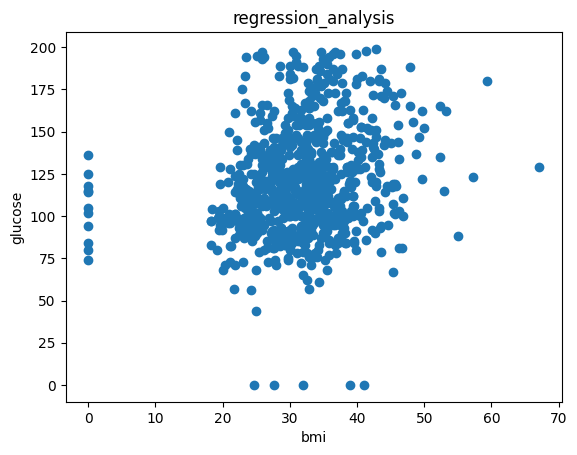

In [46]:
plt.scatter(X,y)
plt.title("regression_analysis")
plt.xlabel("bmi")
plt.ylabel("glucose")
plt.show()

In [49]:
reg = LinearRegression()

reg.fit(X,y)
prediction = reg.predict(X)


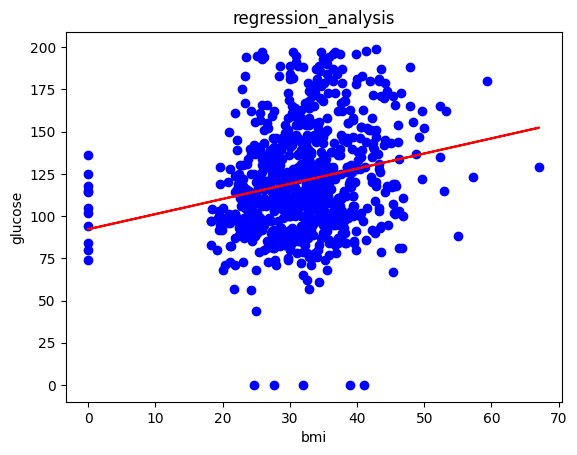

In [52]:
plt.scatter(X,y, color="blue")
plt.title("regression_analysis")
plt.xlabel("bmi")
plt.ylabel("glucose")

plt.plot(X,prediction,color="red")
plt.show()



In [55]:
#multiple linear regression


X = df1.drop("glucose",axis=1).values
y = df1["glucose"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3, random_state=31)

reg = LinearRegression()

reg.fit(X_train, y_train)

y_pred = reg.predict(X_test)

print("Predictions: {}, Actual Values: {}".format(y_pred[:2], y_test[:2]))

Predictions: [ 99.0091324  110.06448426], Actual Values: 55     73
87    100
Name: glucose, dtype: int64


In [58]:
from sklearn.metrics import mean_squared_error

In [60]:
r_squared = reg.score(X_test, y_test)
print("r_squared:{}".format(r_squared))

r_squared:0.3132902483038863


In [63]:
rmse = mean_squared_error(y_test, y_pred)
print("rmse:{}".format(rmse))

rmse:723.5098839616007


## Cross validation

In [64]:
X = df1["bmi"].values
y = df1["glucose"].values

X = X.reshape(-1,1)

print(X.shape, y.shape)

(768, 1) (768,)


In [65]:
from sklearn.model_selection import cross_val_score, KFold
kf = KFold(n_splits=6, shuffle=True, random_state=6)

reg = LinearRegression()

cv_scores = cross_val_score(reg, X, y, cv=kf)

print(cv_scores)

[0.05929756 0.01139372 0.04462196 0.06261067 0.0523336  0.01200906]


In [67]:
#mean, median & 95% CI

print(np.mean(cv_scores))
print(np.std(cv_scores))

print(np.quantile(cv_scores,[0.025,0.975]))

0.04037776008939039
0.021047857483309843
[0.01147064 0.06219653]


## regularization tchnique in LR (to avoid over fitting)

1. Ridge